In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
import warnings
warnings.filterwarnings("ignore")

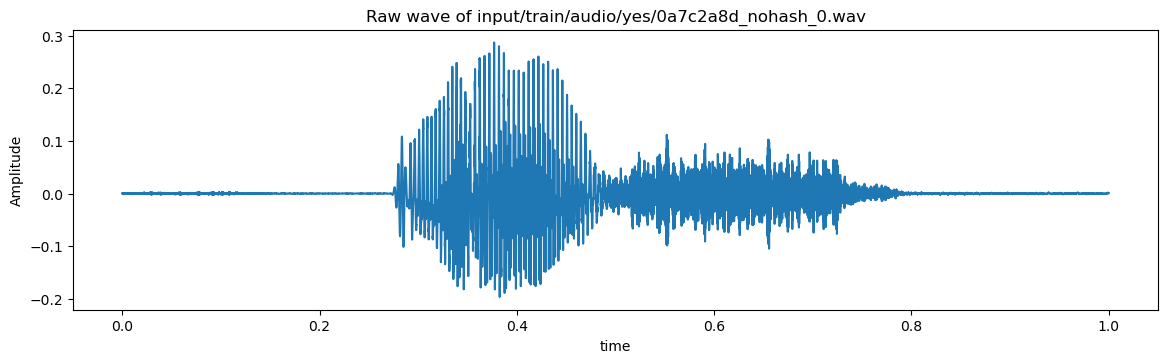

In [6]:
train_audio_path = './data/train/train/audio/'
samples, sample_rate = librosa.load(train_audio_path+'yes/0a7c2a8d_nohash_0.wav', sr = 16000)
fig = plt.figure(figsize=(14, 8))
ax1 = fig.add_subplot(211)
ax1.set_title('Raw wave of ' + 'input/train/audio/yes/0a7c2a8d_nohash_0.wav')
ax1.set_xlabel('time')
ax1.set_ylabel('Amplitude')
ax1.plot(np.linspace(0, sample_rate/len(samples), sample_rate), samples)

In [7]:
ipd.Audio(samples, rate=sample_rate)

In [8]:
print(sample_rate)

16000


In [9]:
samples_resampled = librosa.resample(samples, orig_sr=sample_rate, target_sr=8000)
ipd.Audio(samples_resampled, rate=8000)


In [10]:
labels = os.listdir(train_audio_path)


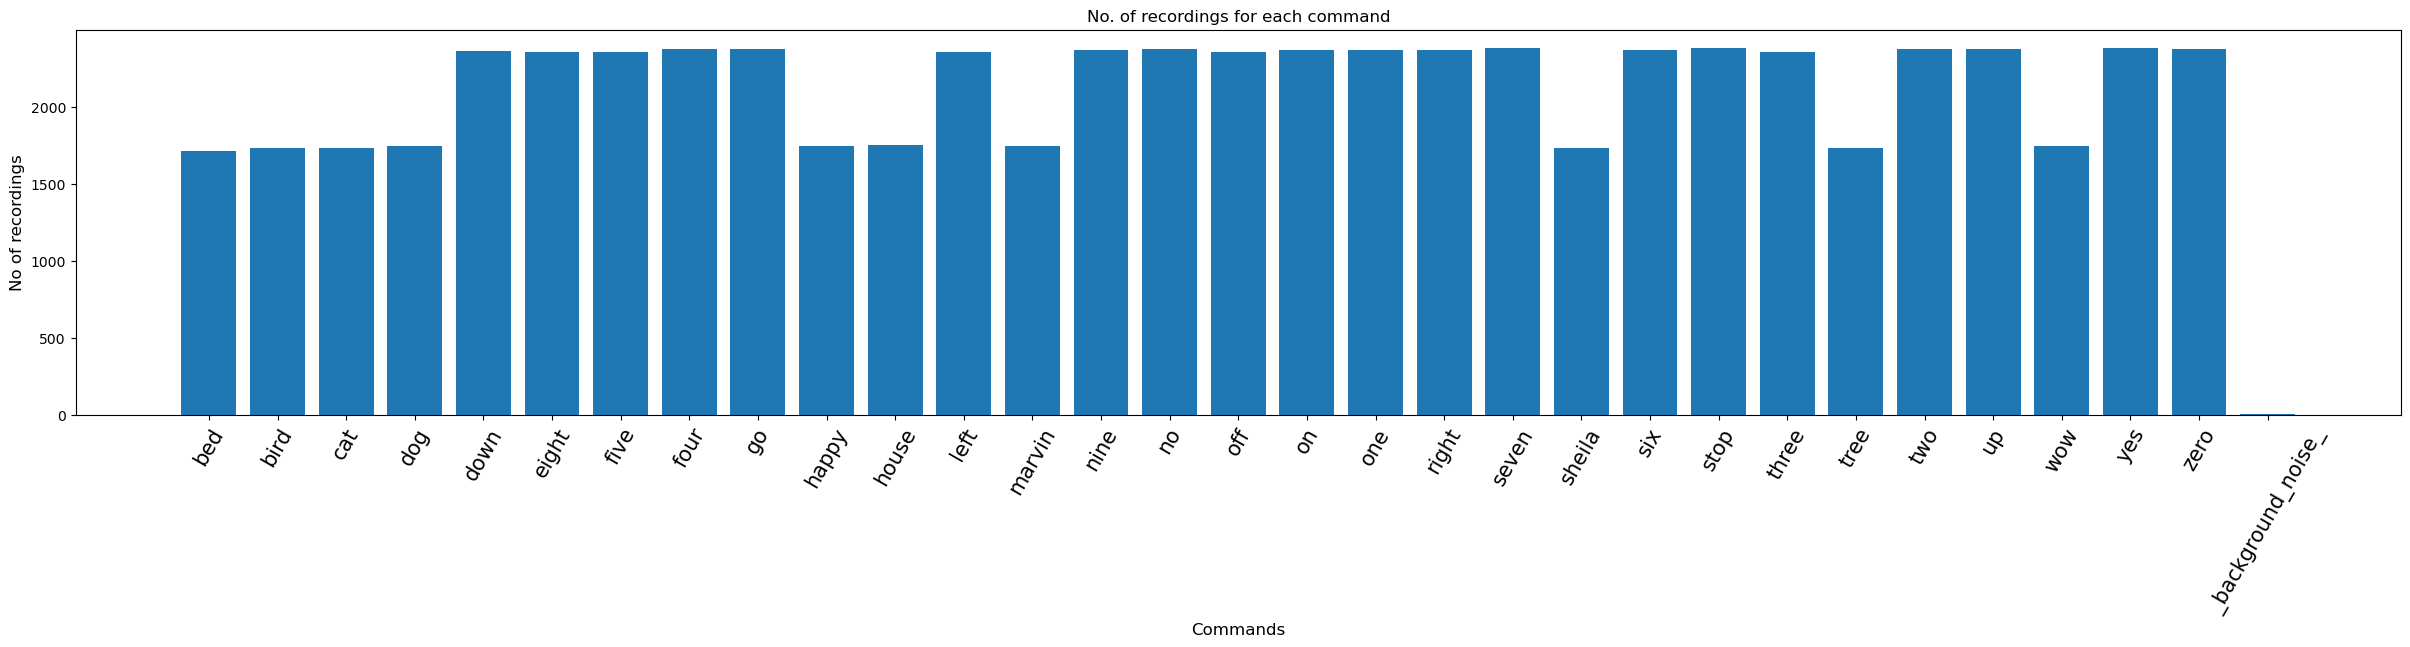

In [11]:
no_of_recordings = []
for label in labels:
    waves = [f for f in os.listdir(train_audio_path+'/'+label) if f.endswith('.wav')]
    no_of_recordings.append(len(waves))

#plot
plt.figure(figsize=(30,5))
index = np.arange(len(labels))
plt.bar(index, no_of_recordings)
plt.xlabel('Commands', fontsize=12)
plt.ylabel('No of recordings', fontsize=12)
plt.xticks(index, labels, fontsize=15, rotation=60)
plt.title('No. of recordings for each command')
plt.show()




(array([1.5000e+01, 3.0000e+01, 4.4000e+01, 1.3800e+02, 1.3600e+02,
        1.7900e+02, 3.6600e+02, 4.3400e+02, 5.9300e+02, 2.1747e+04]),
 array([0.418 , 0.4762, 0.5344, 0.5926, 0.6508, 0.709 , 0.7672, 0.8254,
        0.8836, 0.9418, 1.    ]),
 <BarContainer object of 10 artists>)

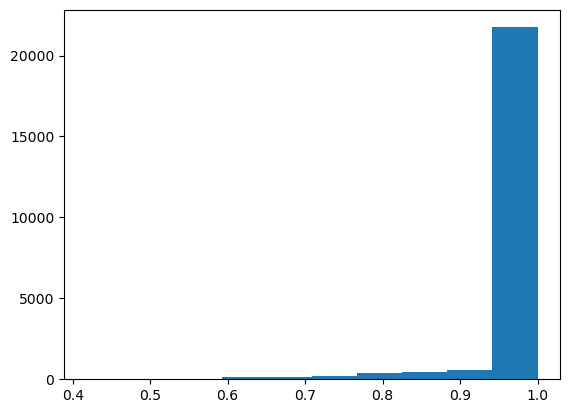

In [12]:
labels=["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
duration_of_recordings=[]
for label in labels:
      waves = [f for f in os.listdir(train_audio_path+'/'+label) if f.endswith('.wav')]
      for wav in waves:
        sample_rate, samples = wavfile.read(train_audio_path + '/' + label + '/' + wav)
        duration_of_recordings.append(float(len(samples)/sample_rate))

plt.hist(np.array(duration_of_recordings))

In [14]:
train_audio_path = './data/train/train/audio/'
all_wave = []
all_label = []
for label in labels:
    print(label)
    waves = [f for f in os.listdir(train_audio_path + '/'+ label) if f.endswith('.wav')]
    for wav in waves:
        samples, sample_rate = librosa.load(train_audio_path + '/' + label + '/' + wav, sr = 16000)
        samples = librosa.resample(samples, orig_sr=sample_rate, target_sr=8000)
        if(len(samples)== 8000) :
            all_wave.append(samples)
            all_label.append(label)

yes
no
up
down
left
right
on
off
stop
go


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(all_label)
classes = list(le.classes_)


In [16]:
from tensorflow.keras import utils as utils
y = utils.to_categorical(y, num_classes = len(labels))


In [17]:
all_wave = np.array(all_wave).reshape(-1, 8000, 1)


In [18]:
from sklearn.model_selection import train_test_split
x_tr, x_val, y_tr, y_val = train_test_split(np.array(all_wave), np.array(y), stratify=y, test_size=0.2, random_state=777, shuffle=True)

In [19]:
from tensorflow import keras as keras

In [20]:
import tensorflow.keras as keras
from tensorflow.keras import Input, layers
from tensorflow.keras import backend as K

In [21]:
K.clear_session()

In [22]:
inputs = Input(shape=(8000,1))
#First Conv1D layer
conv = layers.Conv1D(8,13, padding='valid', activation='relu',strides=1)(inputs)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Second Conv1D layer
conv = layers.Conv1D(16, 11, padding='valid', activation='relu',strides=1)(conv)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Third Conv1D layer
conv = layers.Conv1D(32, 9, padding='valid', activation='relu', strides=1)(conv)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Fourth Conv1D layer
conv = layers.Conv1D(64, 7, padding='valid', activation='relu', strides=1)(conv)
conv = layers.MaxPooling1D(3)(conv)
conv = layers.Dropout(0.3)(conv)
#Flatten layer
conv = layers.Flatten()(conv)
# Dense Layer 1
conv = layers.Dense(256, activation='relu')(conv)
conv = layers.Dropout(0.3)(conv)
#Dense Layer 2
conv = layers.Dense(128, activation='relu')(conv)
conv = layers.Dropout(0.3)(conv)
outputs = layers.Dense(len(labels), activation='softmax')(conv)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 8000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 7988, 8)        │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2662, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2662, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2652, 16)       │         1,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 884, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 884, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 876, 32)        │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 292, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 292, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 286, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 95, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 95, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6080)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,556,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,611,498 (6.15 MB)

 Trainable params: 1,611,498 (6.15 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [24]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [35]:
es = EarlyStopping(monitor = 'val_loss', mode = 'min', verbose = 1, patience = 10, min_delta = 0.0001)
mc = ModelCheckpoint('best_model_check.keras', monitor = 'val_acc', verbose = 1, save_best_only = True, mode = 'max')

In [36]:
history=model.fit(x_tr, y_tr ,epochs=100, callbacks=[es,mc], batch_size=32,validation_data=(x_val,y_val))

Epoch 1/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.9307 - loss: 0.2176 - val_accuracy: 0.8571 - val_loss: 0.4822
Epoch 2/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 23s 42ms/step - accuracy: 0.9327 - loss: 0.1993 - val_accuracy: 0.8623 - val_loss: 0.4887
Epoch 3/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9319 - loss: 0.2015 - val_accuracy: 0.8581 - val_loss: 0.5139
Epoch 4/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9378 - loss: 0.1825 - val_accuracy: 0.8503 - val_loss: 0.5524
Epoch 5/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 24s 44ms/step - accuracy: 0.9336 - loss: 0.2053 - val_accuracy: 0.8426 - val_loss: 0.5632
Epoch 6/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.9346 - loss: 0.1966 - val_accuracy: 0.8487 - val_loss: 0.5164
Epoch 7/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 27s 50ms/step - accuracy: 0.9356 - loss: 0.1943 - val_accuracy: 0.8501 - val_loss: 0.5279
Epoch 8/100
533/533 ━━━━━━━━━━━━━━━━━━━━ 28s 52ms/step - accuracy: 0.9317 - loss: 0

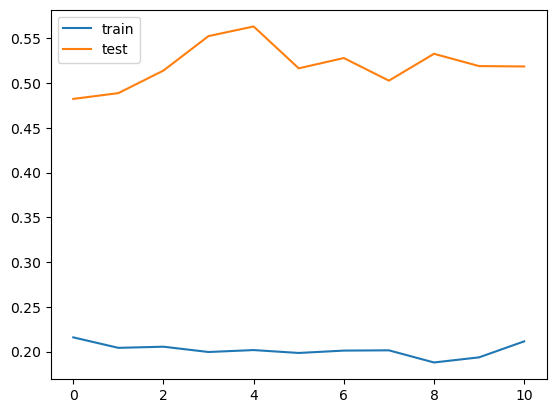

In [37]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [ ]:
from keras.models import load_model
model = load_model('best_model.keras')


In [39]:
def predict(audio):
    prob=model.predict(audio.reshape(1,8000,1))
    index=np.argmax(prob[0])
    return classes[index]

In [40]:
import random
index=random.randint(0,len(x_val)-1)
samples=x_val[index].ravel()
print("Audio:",classes[np.argmax(y_val[index])])
ipd.Audio(samples, rate=8000)

Audio: stop


In [41]:
print("Text:",predict(samples))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Text: stop


In [42]:
pip install sounddevice

   ---------------------------------------- 0.0/363.6 kB ? eta -:--:--
   - -------------------------------------- 10.2/363.6 kB ? eta -:--:--
   -- ------------------------------------ 20.5/363.6 kB 320.0 kB/s eta 0:00:02
   --- ----------------------------------- 30.7/363.6 kB 217.9 kB/s eta 0:00:02
   ---- ---------------------------------- 41.0/363.6 kB 217.9 kB/s eta 0:00:02
   ------- ------------------------------- 71.7/363.6 kB 301.2 kB/s eta 0:00:01
   --------- ----------------------------- 92.2/363.6 kB 348.6 kB/s eta 0:00:01
   -------------- ----------------------- 143.4/363.6 kB 472.1 kB/s eta 0:00:01
   -------------------- ----------------- 194.6/363.6 kB 560.2 kB/s eta 0:00:01
   ----------------------- -------------- 225.3/363.6 kB 573.4 kB/s eta 0:00:01
   ----------------------------- -------- 286.7/363.6 kB 631.2 kB/s eta 0:00:01
   -------------------------------------  358.4/363.6 kB 717.9 kB/s eta 0:00:01
   -------------------------------------- 363.6/363.6 kB 

DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\jiter-0.8.2-py3.12-win-amd64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\langchain_text_splitters-0.3.5-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\langsmith-0.3.2-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\mcqgenerator-0.0.1-py3.12.egg is depre

In [43]:
pip install soundfile

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\jiter-0.8.2-py3.12-win-amd64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\langchain_text_splitters-0.3.5-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\langsmith-0.3.2-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at c:\users\aazhm\anaconda3\lib\site-packages\mcqgenerator-0.0.1-py3.12.egg is depre

In [44]:
import sounddevice as sd
import soundfile as sf
samplerate = 16000
duration = 1 # seconds
filename = 'yes.wav'
print("start")
mydata = sd.rec(int(samplerate * duration), samplerate=samplerate,
channels=1, blocking=True)
print("end")
sd.wait()
sf.write(filename, mydata, samplerate)

start
end


In [45]:
ls yes.wav

 Volume in drive F has no label.
 Volume Serial Number is 9C63-D305

 Directory of f:\applied ML\lab_6

25/03/2025  22:39            32,044 yes.wav
               1 File(s)         32,044 bytes
               0 Dir(s)  26,811,650,048 bytes free


In [46]:
#Load the recorded wav file..
samples, sample_rate = librosa.load('yes.wav', sr = 16000)

In [47]:
ipd.Audio(samples, rate=sample_rate)

In [49]:
#reading the voice commands
samples, sample_rate = librosa.load('yes.wav', sr = 16000)
samples = librosa.resample(y=samples, orig_sr=sample_rate, target_sr=8000)

# Play the resampled audio
ipd.Audio(samples, rate=8000)

In [50]:
#converting voice commands to text
predict(samples)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


'off'